In [1]:
# Install & load dataset
!pip install -q datasets
from datasets import load_dataset
import pandas as pd

ds = load_dataset("Yelp/yelp_review_full")
train = pd.DataFrame(ds['train'])
test  = pd.DataFrame(ds['test'])
dataset = pd.concat([train, test], ignore_index=True)
dataset['stars'] = dataset['label'] + 1        # map label 0-4 -> stars 1-5


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

yelp_review_full/train-00000-of-00001.pa(…):   0%|          | 0.00/299M [00:00<?, ?B/s]

yelp_review_full/test-00000-of-00001.par(…):   0%|          | 0.00/23.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/650000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [2]:
# Import libraries and required downloads
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.probability import FreqDist
from wordcloud import WordCloud

nltk.download('stopwords', 'vader_lexicon', 'omw-1.4' 'punkt', 'wordnet')

True

In [3]:
#Map stars for sentiment
def map_sentiment_from_label(label):
    if label in [0,1]:
        return 'negative'
    elif label == 2:
        return 'neutral'
    else:
        return 'positive'

dataset['sentiment'] = dataset['label'].apply(map_sentiment_from_label)
dataset[['label','stars','sentiment']].head()

,label,stars,sentiment
0,4,5,positive
1,1,2,negative
2,3,4,positive
3,3,4,positive
4,0,1,negative


In [4]:
#Subsample safely to reduce runtime
sample_size = 3000
dataset = dataset.sample(n=sample_size, random_state=42).reset_index(drop=True)
print("Subsample size:", dataset.shape)

Subsample size: (3000, 4)


In [5]:
dataset['sentiment'].value_counts()

,count
sentiment,
positive,1186
negative,1186
neutral,628


Exploratory Data Analysis

In [6]:
dataset

,label,text,stars,sentiment
0,2,I stopped in between sessions at a conference ...,3,neutral
1,3,"The Seafarer, like all Southern \""Fish Camps\""...",4,positive
2,4,It's normal to travel 370 miles specifically f...,5,positive
3,2,We went on Saturday night to satiate my cravin...,3,neutral
4,1,My husband and I were headed to Mellow Mushroo...,2,negative
...,...,...,...,...
2995,2,Burger was really big and good. Wings were go...,3,neutral
2996,4,What could I possibly not be pleased with Fez'...,5,positive
2997,4,I am always pleased at Galileo's. The food is ...,5,positive
2998,0,Sir Edmond BLAND's is what it should be called...,1,negative


In [7]:
dataset.head()

,label,text,stars,sentiment
0,2,I stopped in between sessions at a conference ...,3,neutral
1,3,"The Seafarer, like all Southern \""Fish Camps\""...",4,positive
2,4,It's normal to travel 370 miles specifically f...,5,positive
3,2,We went on Saturday night to satiate my cravin...,3,neutral
4,1,My husband and I were headed to Mellow Mushroo...,2,negative


In [8]:
dataset.tail()

,label,text,stars,sentiment
2995,2,Burger was really big and good. Wings were go...,3,neutral
2996,4,What could I possibly not be pleased with Fez'...,5,positive
2997,4,I am always pleased at Galileo's. The food is ...,5,positive
2998,0,Sir Edmond BLAND's is what it should be called...,1,negative
2999,0,It wouldnt matter if I had all the riches in t...,1,negative


In [9]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   label      3000 non-null   int64 
 1   text       3000 non-null   object
 2   stars      3000 non-null   int64 
 3   sentiment  3000 non-null   object
dtypes: int64(2), object(2)
memory usage: 93.9+ KB


In [10]:
dataset.describe()

,label,stars
count,3000.000000,3000.000000
mean,2.008333,3.008333
std,1.398660,1.398660
min,0.000000,1.000000
25%,1.000000,2.000000
50%,2.000000,3.000000
75%,3.000000,4.000000
max,4.000000,5.000000


In [11]:
dataset.isnull().sum()

,0
label,0
text,0
stars,0
sentiment,0


NLTK

VADER (Valence Aware Dictionary and Sentiment Reasoner)

In [12]:
#NLTK VADER
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')
sentiment = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [39]:
dataset['compound'] = [sentiment.polarity_scores(text)['compound'] for text in dataset['text']]
dataset['neg'] = [sentiment.polarity_scores(text)['neg'] for text in dataset['text']]
dataset['neu'] = [sentiment.polarity_scores(text)['neu'] for text in dataset['text']]
dataset['pos'] = [sentiment.polarity_scores(text)['pos'] for text in dataset['text']]

In [41]:
dataset[['compound','neg','neu','pos']].describe()

,compound,neg,neu,pos
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,0.524306,0.057760,0.773817,0.168425
std,0.630668,0.062511,0.106646,0.114639
min,-0.994600,0.000000,0.000000,0.000000
25%,0.296000,0.008000,0.724000,0.091000
50%,0.870850,0.044000,0.790000,0.147000
75%,0.965600,0.084000,0.841000,0.219000
max,0.999600,0.697000,1.000000,0.849000


In [42]:
#Define sentiment categories using VADER compound thresholds
def vader_label(compound):
    if compound <= 0:
        return 'negative'
    elif -0.05 < compound < 0.05:
        return 'neutral'
    else:
        return 'positive'

#New column using VADER Compound
dataset['vader_sentiment'] = dataset['compound'].apply(vader_label)

In [16]:
# Show counts
dataset['vader_sentiment'].value_counts()

,count
vader_sentiment,
positive,2342
negative,652
neutral,6


Preprocessing

In [17]:
nltk.download('stopwords')
tokenizer = RegexpTokenizer(r"[A-Za-z']+")       # keeps words and apostrophes
stop_words = set(stopwords.words('english'))     # stopwords
stemmer = PorterStemmer()                        # Porter stemmer

def tokenize_text(text):
    return tokenizer.tokenize(str(text))

def remove_stopwords(tokens):
    return [t for t in tokens if t.lower() not in stop_words]

def stem_tokens(tokens):
    return [stemmer.stem(t) for t in tokens]


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [18]:
#Appling preprocessing to the sampled dataset
def preprocess_row(text):
    toks = tokenize_text(text)                # tokenise
    toks_ns = remove_stopwords(toks)          # remove stopwords
    toks_stem = stem_tokens(toks_ns)          # stem tokens
    cleaned = " ".join([t.lower() for t in toks_stem])
    return toks, toks_ns, toks_stem, cleaned

dataset_processed = dataset.copy()
dataset_processed[['tokens','tokens_nostop','tokens_stem','cleaned_text']] = \
    dataset_processed['text'].apply(lambda t: pd.Series(preprocess_row(t)))


In [19]:
# head() after preprocessing)
dataset_processed[['text','cleaned_text','sentiment']].head()

,text,cleaned_text,sentiment
0,I stopped in between sessions at a conference ...,stop session confer venetian took whole minut ...,neutral
1,"The Seafarer, like all Southern \""Fish Camps\""...",seafar like southern fish camp serv sort seafo...,positive
2,It's normal to travel 370 miles specifically f...,normal travel mile specif restaur right soon b...,positive
3,We went on Saturday night to satiate my cravin...,went saturday night satiat crave good karaok n...,neutral
4,My husband and I were headed to Mellow Mushroo...,husband head mellow mushroom saw sign selwyn a...,negative


Distribution of compound, positive, neutral and negative scores

<Axes: xlabel='compound', ylabel='Count'>

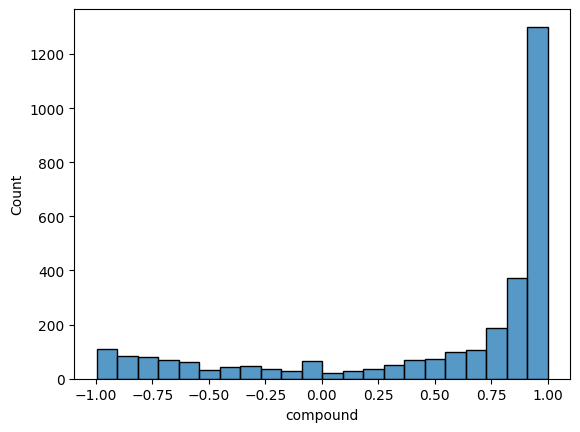

In [20]:
# Distribution of Compound
sns.histplot(dataset['compound'])

<Axes: xlabel='pos', ylabel='Count'>

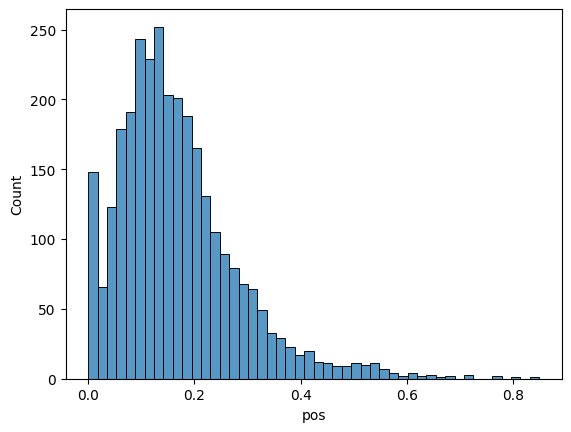

In [21]:
# Distribution of Positive
sns.histplot(dataset['pos'])

<Axes: xlabel='neg', ylabel='Count'>

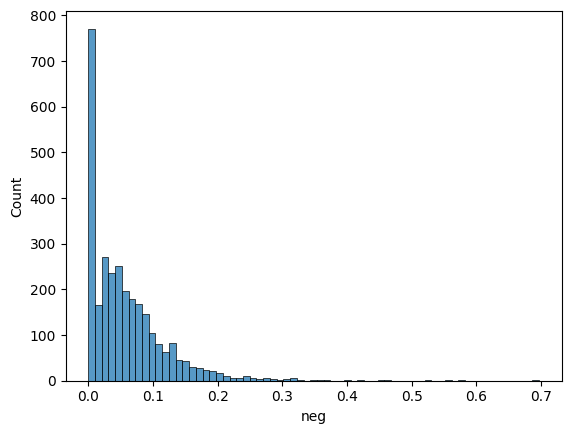

In [22]:
# Distribution of Negative
sns.histplot(dataset['neg'])

<Axes: xlabel='neu', ylabel='Count'>

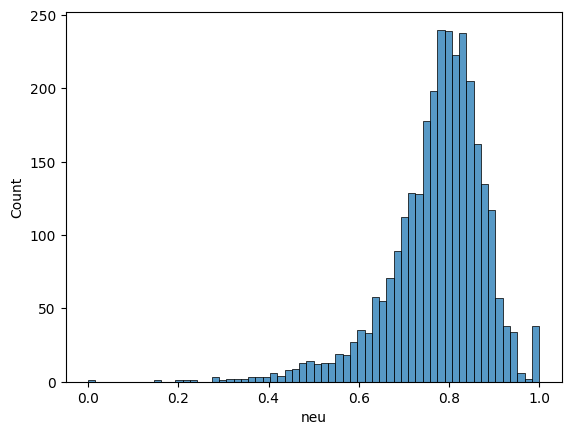

In [23]:
# Distribution of Neutral
sns.histplot(dataset['neu'])

Calculate percentage of total neg / pos / neutral

In [24]:
# Percentage of total negative / neutral / positive (using vader_sentiment)

counts = dataset_processed['vader_sentiment'].value_counts()
percentages = counts / counts.sum() * 100
print("Counts:\n", counts)
print("\nPercentages (%):\n", percentages.round(2))


Counts:
 vader_sentiment
positive    2342
negative     652
neutral        6
Name: count, dtype: int64

Percentages (%):
 vader_sentiment
positive    78.07
negative    21.73
neutral      0.20
Name: count, dtype: float64


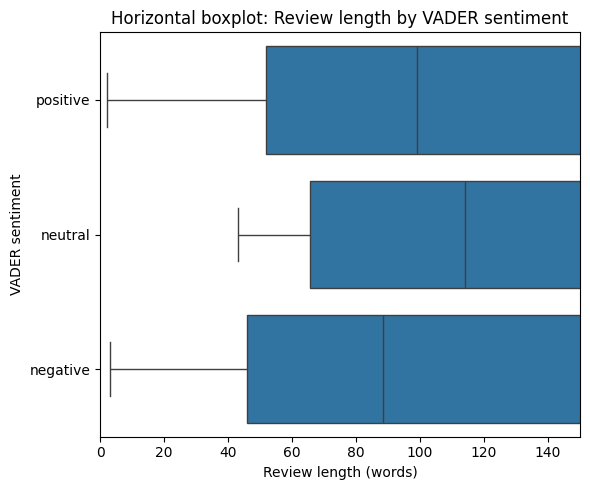

In [34]:
# Horizontal boxplot of review lengths by VADER sentiment
dataset_processed['review_len'] = dataset_processed['text'].str.split().apply(len)

plt.figure(figsize=(6,5))
sns.boxplot(x='review_len', y='vader_sentiment',
            data=dataset_processed,
            order=['positive','neutral','negative'],
            orient='h')
plt.xlim(0,150)
plt.title('Horizontal boxplot: Review length by VADER sentiment')
plt.xlabel('Review length (words)')
plt.ylabel('VADER sentiment')
plt.tight_layout()
plt.show()


WordCloud

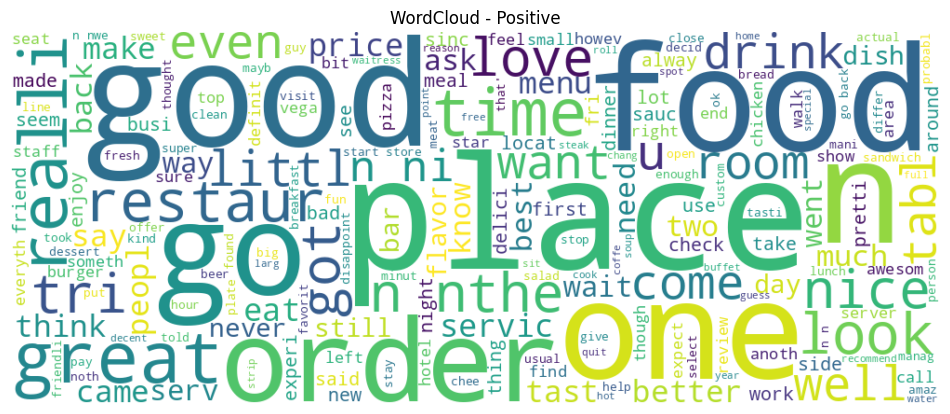

In [26]:
# WordCloud - POSITIVE
positive_text = " ".join(dataset_processed[dataset_processed['vader_sentiment']=='positive']['cleaned_text'].astype(str).tolist())
wc_pos = WordCloud(width=1000, height=400, background_color='white', max_words=200).generate(positive_text)
plt.figure(figsize=(12,6))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off'); plt.title('WordCloud - Positive')
plt.show()


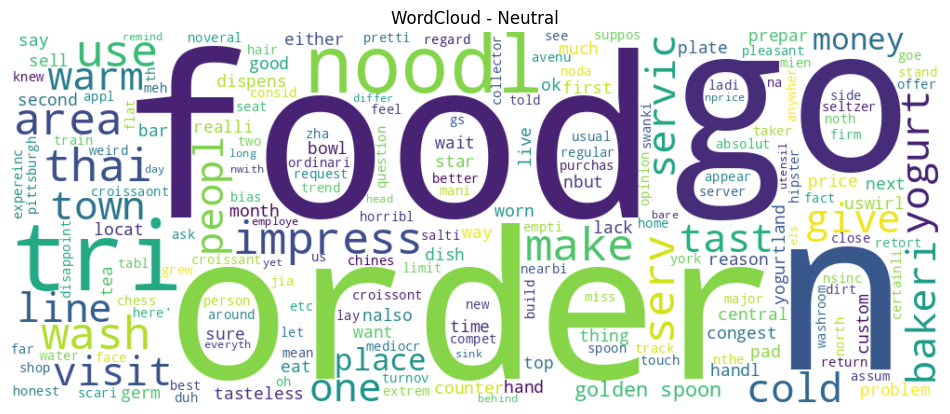

In [27]:
#WordCloud - NEUTRAL
neutral_text = " ".join(dataset_processed[dataset_processed['vader_sentiment']=='neutral']['cleaned_text'].astype(str).tolist())
wc_neu = WordCloud(width=1000, height=400, background_color='white', max_words=200).generate(neutral_text)
plt.figure(figsize=(12,6))
plt.imshow(wc_neu, interpolation='bilinear')
plt.axis('off'); plt.title('WordCloud - Neutral')
plt.show()


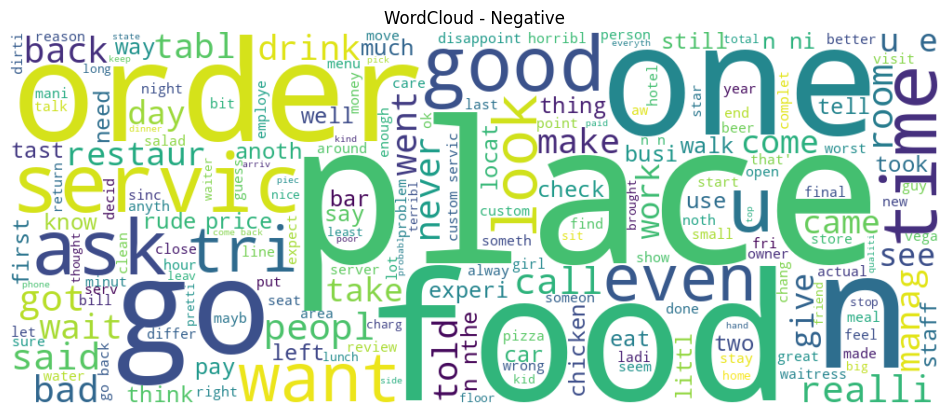

In [28]:
# WordCloud - NEGATIVE
negative_text = " ".join(dataset_processed[dataset_processed['vader_sentiment']=='negative']['cleaned_text'].astype(str).tolist())
wc_neg = WordCloud(width=1000, height=400, background_color='white', max_words=200).generate(negative_text)
plt.figure(figsize=(12,6))
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off'); plt.title('WordCloud - Negative')
plt.show()


Frequency distribution

In [29]:
#  Frequency distribution - POSITIVE words
from collections import Counter

pos_tokens = [tok for toks in dataset_processed[dataset_processed['vader_sentiment']=='positive']['tokens_nostop'] for tok in toks]
fd_pos = FreqDist(pos_tokens)
top_pos = fd_pos.most_common(20)
words_pos, counts_pos = zip(*top_pos)


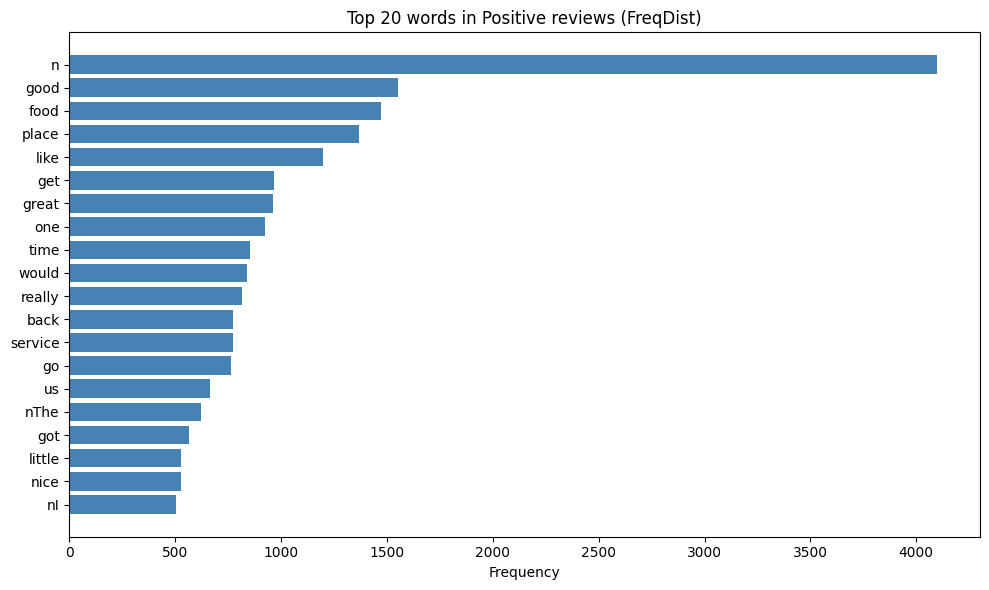

In [30]:
#Positive reviews
plt.figure(figsize=(10,6))
plt.barh(range(len(words_pos)), counts_pos, color='steelblue')
plt.yticks(range(len(words_pos)), words_pos)
plt.gca().invert_yaxis()
plt.title('Top 20 words in Positive reviews (FreqDist)')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

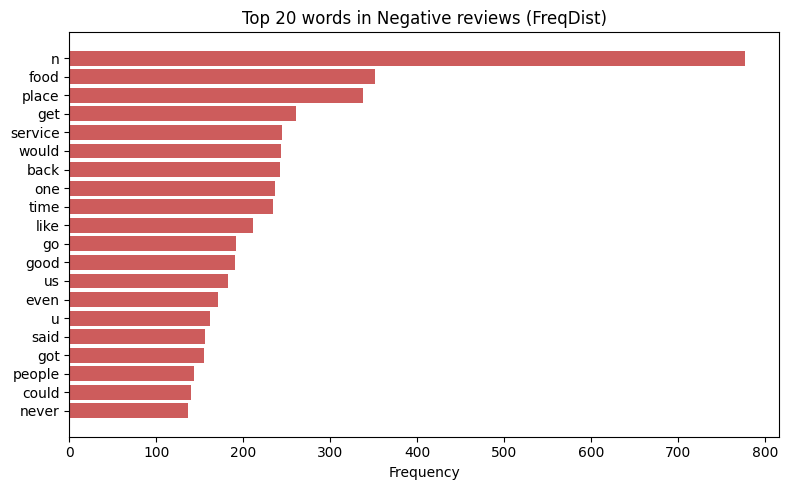

In [35]:
# Frequency distribution - NEGATIVE words
neg_tokens = [tok for toks in dataset_processed[dataset_processed['vader_sentiment']=='negative']['tokens_nostop'] for tok in toks]
fd_neg = FreqDist(neg_tokens)
top_neg = fd_neg.most_common(20)
words_neg, counts_neg = zip(*top_neg)

plt.figure(figsize=(8,5))
plt.barh(range(len(words_neg)), counts_neg, color='indianred')
plt.yticks(range(len(words_neg)), words_neg)
plt.gca().invert_yaxis()
plt.title('Top 20 words in Negative reviews (FreqDist)')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()


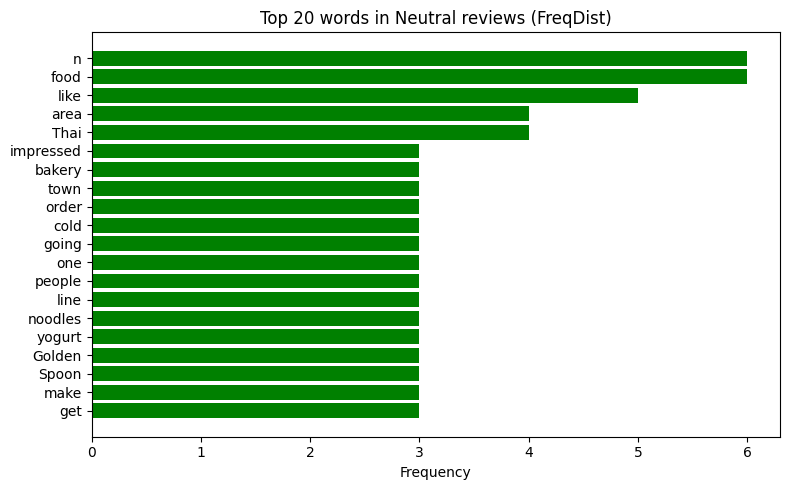

In [36]:
#  Frequency distribution - NEUTRAL words (FreqDist)
neu_tokens = [tok for toks in dataset_processed[dataset_processed['vader_sentiment']=='neutral']['tokens_nostop'] for tok in toks]
fd_neu = FreqDist(neu_tokens)
top_neu = fd_neu.most_common(20)
words_neu, counts_neu = zip(*top_neu)

plt.figure(figsize=(8,5))
plt.barh(range(len(words_neu)), counts_neu, color='green')
plt.yticks(range(len(words_neu)), words_neu)
plt.gca().invert_yaxis()
plt.title('Top 20 words in Neutral reviews (FreqDist)')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()
